# F3-D — LoRA Fine-Tuning + Ensemble Ponderado

**Objetivo**: Fine-tuning con LoRA de DistilBERT + Ensemble ponderado (RF + XGBoost + LoRA). Notebook GPU.

**Tiempo estimado**: ~2h (GPU T4)


In [4]:
!pip install -q torchao -U
!pip install -q mlflow -U
!pip install -q peft -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 29.3 MB/s eta 0:00:00


## 1. Cargar datos y configurar GPU


In [5]:
import gc
import json
import os
import pickle
import sys
import time
import warnings

from datasets import Dataset
from google.colab import drive
import joblib
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
from pathlib import Path
from peft import LoraConfig, TaskType, get_peft_model
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
)
import torch
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict

# Configuración de advertencias
warnings.filterwarnings('ignore')

## 2. Montar Google Drive y cargar datos


In [3]:
# 1. Determinación estricta del entorno
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/ML/proyecto_integrador')
else:
    BASE_PATH = Path('..')

# 2. Definición estructurada de rutas del proyecto
DATA_PATH = BASE_PATH / "data"
MODELS_PATH = BASE_PATH / "models"
REPORTS_PATH = BASE_PATH / "reports"
EMB_PATH = BASE_PATH / "embeddings"
PREDS_PATH = BASE_PATH / "preds"

# Crear directorios si no existen
for folder in [MODELS_PATH, REPORTS_PATH, PREDS_PATH]:
    folder.mkdir(parents=True, exist_ok=True)

# 3. Configuración obligatoria de Dispositivo (GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type != "cuda":
    print("[ADVERTENCIA CRÍTICA]: ¡La GPU no está disponible! El rendimiento será deficiente.")

# 4. Monitoreo de recursos del sistema
print(f"=== Información del Entorno ===")
print(f"Entorno Colab: {IN_COLAB}")
print(f"Dispositivo asignado en PyTorch: {device}")
if device.type == "cuda":
    print(f"Modelo de GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memoria de GPU Total: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.1f} GB")

try:
    import psutil
    print(f"Memoria RAM del Sistema: {psutil.virtual_memory().total / (1024**3):.1f} GB")
except ImportError:
    pass

print(f"Ruta Base del Proyecto: {BASE_PATH}")

Mounted at /content/drive
=== Environment Info ===
IN_COLAB: True
HAS_CUDA: True
HAS_CUDF: True
HAS_TORCH: True
GPU Memory: 14.6 GB
System RAM: 12.7 GB
BASE: /content/drive/MyDrive/ML/proyecto_integrador
DATA_PATH: /content/drive/MyDrive/ML/proyecto_integrador/data
MODELS_PATH: /content/drive/MyDrive/ML/proyecto_integrador/models


In [2]:
# Configuración global del experimento
RANDOM_STATE = 42
BATCH_SIZE = 256
MAX_LENGTH = 128

# Fijar semillas para reproducibilidad si es necesario
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if device.type == "cuda":
    torch.cuda.manual_seed_all(RANDOM_STATE)

In [6]:
print("Cargando embeddings, features y textos desde el almacenamiento...")

# 1. Carga de Embeddings de manera segura
X_train_emb = np.load(EMB_PATH / "train_embeddings.npy")
X_val_emb   = np.load(EMB_PATH / "val_embeddings.npy")
X_test_emb  = np.load(EMB_PATH / "test_embeddings.npy")

# 2. Carga de características de ingeniería (Engineered features)
eng_train = np.load(EMB_PATH / "train_eng_features.npy")
eng_val   = np.load(EMB_PATH / "val_eng_features.npy")
eng_test  = np.load(EMB_PATH / "test_eng_features.npy")

# 3. Carga de Etiquetas (Labels)
y_train = np.load(EMB_PATH / "train_labels.npy")
y_val   = np.load(EMB_PATH / "val_labels.npy")
y_test  = np.load(EMB_PATH / "test_labels.npy")

# 4. Carga de Textos crudos en formato Pickle (Específico para LoRA/Transformers)
with open(EMB_PATH / "train_texts.pkl", 'rb') as f:
    X_train_texts = pickle.load(f)
with open(EMB_PATH / "val_texts.pkl", 'rb') as f:
    X_val_texts = pickle.load(f)
with open(EMB_PATH / "test_texts.pkl", 'rb') as f:
    X_test_texts = pickle.load(f)

# 5. Concatenación de matrices para algoritmos clásicos de Machine Learning
X_train = np.concatenate([X_train_emb, eng_train], axis=1)
X_val   = np.concatenate([X_val_emb, eng_val], axis=1)
X_test  = np.concatenate([X_test_emb, eng_test], axis=1)

print("\n=== Resumen de Datos Cargados ===")
print(f"Muestras de Entrenamiento : {len(X_train_texts)} | Formato X clásico: {X_train.shape}")
print(f"Muestras de Validación    : {len(X_val_texts)} | Formato X clásico: {X_val.shape}")
print(f"Muestras de Prueba        : {len(X_test_texts)} | Formato X clásico: {X_test.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cargando embeddings, features y textos desde F3-A...
Datos cargados: train 350198, val 74800, test 75000


## 3. Cargar predicciones de RF y XGBoost (desde F3-B)

Si no existen (porque F3-B no se ejecutó), se cargan modelos pre-entrenados.


In [7]:
# Archivo de control para verificar si la fase previa existe
results_json_path = PREDS_PATH / "part1_results.json"

if (PREDS_PATH / "y_pred_rf.npy").exists() and results_json_path.exists():
    print("Cargando predicciones existentes desde el almacenamiento...")
    # ... (Se mantiene igual tu lógica de carga)
    y_pred_rf = np.load(PREDS_PATH / "y_pred_rf.npy")
    y_pred_xgb = np.load(PREDS_PATH / "y_pred_xgb.npy")

    with open(results_json_path, 'r') as f:
        part1_results = json.load(f)

    rf_metrics = [r for r in part1_results if r['model_name'] == 'Random Forest'][0]
    xgb_metrics = [r for r in part1_results if r['model_name'] == 'XGBoost'][0]
    print(f"RF F1: {rf_metrics['f1_macro']:.4f} | XGB F1: {xgb_metrics['f1_macro']:.4f}")

else:
    print("Predicciones no encontradas. Iniciando entrenamiento con validación cruzada (Out-of-Fold)...")

    # Configurar la validación cruzada
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    # ==========================================
    # 1. Random Forest (Paralelizado en CPU)
    # ==========================================
    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight='balanced'
    )

    # Generar predicciones OOF para evitar data leakage en el stacking
    print("Generando probabilidades OOF para Random Forest...")
    rf_oof_proba = cross_val_predict(rf, X_train, y_train, cv=skf, method='predict_proba', n_jobs=-1)

    # Entrenar en TODO X_train para tener el modelo final que predecirá X_val y X_test
    print("Entrenando Random Forest final...")
    rf.fit(X_train, y_train)
    rf_val_proba = rf.predict_proba(X_val)
    rf_test_proba = rf.predict_proba(X_test)
    y_pred_rf = rf.predict(X_test)

    # Guardar salidas de RF
    np.save(PREDS_PATH / "rf_train.npy", rf_oof_proba.argmax(axis=1))
    np.save(PREDS_PATH / "rf_val.npy", rf_val_proba.argmax(axis=1))
    np.save(PREDS_PATH / "rf_proba_train.npy", rf_oof_proba)
    np.save(PREDS_PATH / "rf_proba_val.npy", rf_val_proba)
    np.save(PREDS_PATH / "rf_proba_test.npy", rf_test_proba)

    # ==========================================
    # 2. XGBoost (Ejecutándose en GPU)
    # ==========================================
    xgb = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        eval_metric='mlogloss',
        tree_method='hist',
        device='cuda'
    )

    sample_weights = compute_sample_weight('balanced', y_train)

    print("Generando probabilidades OOF para XGBoost...")
    xgb_oof_proba = cross_val_predict(
        xgb, X_train, y_train, cv=skf, method='predict_proba',
        fit_params={'sample_weight': sample_weights}
    )

    # Entrenar en TODO X_train para el modelo final
    print("Entrenando XGBoost final...")
    xgb.fit(
        X_train, y_train,
        sample_weight=sample_weights,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    xgb_val_proba = xgb.predict_proba(X_val)
    xgb_test_proba = xgb.predict_proba(X_test)
    y_pred_xgb = xgb.predict(X_test)

    # Guardar salidas de XGBoost
    np.save(PREDS_PATH / "xgb_train.npy", xgb_oof_proba.argmax(axis=1))
    np.save(PREDS_PATH / "xgb_val.npy", xgb_val_proba.argmax(axis=1))
    np.save(PREDS_PATH / "xgb_proba_train.npy", xgb_oof_proba)
    np.save(PREDS_PATH / "xgb_proba_val.npy", xgb_val_proba)
    np.save(PREDS_PATH / "xgb_proba_test.npy", xgb_test_proba)

    print("Modelos clásicos entrenados con éxito.")

Cargando predicciones de F3-B...
RF F1: 0.6295, XGB F1: 0.6592


## 4. LoRA Fine-Tuning


In [8]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)

# Instanciación inicial
train_ds = Dataset.from_dict({'text': X_train_texts, 'label': y_train})
val_ds   = Dataset.from_dict({'text': X_val_texts, 'label': y_val})
test_ds  = Dataset.from_dict({'text': X_test_texts, 'label': y_test})

# Determinación de núcleos disponibles para paralelizar (dejando 1 libre por seguridad)
num_cores = max(1, os.cpu_count() - 1)

print(f"Iniciando tokenización paralelizada usando {num_cores} núcleos...")

# Mapeo optimizado: paralelización + eliminación de la columna de texto crudo
train_ds = train_ds.map(
    tokenize_fn,
    batched=True,
    num_proc=num_cores,
    remove_columns=['text'],
    desc="Tokenizando entrenamiento"
)
val_ds = val_ds.map(
    tokenize_fn,
    batched=True,
    num_proc=num_cores,
    remove_columns=['text'],
    desc="Tokenizando validación"
)
test_ds = test_ds.map(
    tokenize_fn,
    batched=True,
    num_proc=num_cores,
    remove_columns=['text'],
    desc="Tokenizando prueba"
)

# Forzar el formato de los datos a tensores de PyTorch para eficiencia de memoria
train_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
val_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'f1_macro': f1_score(labels, predictions, average='macro'),
        'accuracy': accuracy_score(labels, predictions)
    }

print("\n=== Datasets preparados y optimizados para PyTorch ===")
print(f"Columnas resultantes: {train_ds.column_names}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/350198 [00:00<?, ? examples/s]

Map:   0%|          | 0/74800 [00:00<?, ? examples/s]

Map:   0%|          | 0/75000 [00:00<?, ? examples/s]

In [9]:
# 1. Instanciación en CPU (Delegamos el traslado a GPU a la clase Trainer)
model_cls = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
)

# 2. Configuración LoRA matemáticamente balanceada
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=32,
    lora_alpha=64, # Ajustado para mantener el factor de escala (64/32 = 2)
    lora_dropout=0.1,
    target_modules=['q_lin', 'k_lin', 'v_lin', 'out_lin']
)

# 3. Inyección de adaptadores en la memoria principal
model_lora = get_peft_model(model_cls, lora_config)

# 4. Auditoría de la arquitectura
model_lora.print_trainable_parameters()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 1,772,547 || all params: 68,728,326 || trainable%: 2.5791


In [10]:
# Corrección de la validación del dispositivo según tu bloque inicial
HAS_CUDA = device.type == "cuda"

lora_args = TrainingArguments(
    output_dir=str(MODELS_PATH / 'lora_checkpoints'), # Uso de rutas centralizadas
    eval_strategy='epoch',
    save_strategy='epoch',
    per_device_train_batch_size=128,
    per_device_eval_batch_size=256,
    num_train_epochs=6,
    lr_scheduler_type='cosine',
    warmup_ratio=0.1, # Se adapta dinámicamente al tamaño del dataset y batch_size
    learning_rate=2e-4,
    weight_decay=0.01,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    report_to='none',
    # Optimizaciones de Hardware
    fp16=HAS_CUDA,
    dataloader_num_workers=4 if HAS_CUDA else 0,
    dataloader_pin_memory=HAS_CUDA,
    gradient_accumulation_steps=1,
    remove_unused_columns=True,
)

trainer_lora = Trainer(
    model=model_lora,
    args=lora_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Iniciando LoRA fine-tuning...")
start = time.time()
trainer_lora.train()
lora_time = time.time() - start
print(f"LoRA completado en {lora_time:.0f}s ({lora_time/3600:.1f}h)")

print("Guardando predicciones de Validación y Prueba...")
# Extracción de predicciones para el conjunto de prueba
test_out = trainer_lora.predict(test_ds)
np.save(PREDS_PATH / "y_pred_lora.npy", test_out.predictions.argmax(-1))
np.save(PREDS_PATH / "lora_probs_test.npy", torch.softmax(torch.tensor(test_out.predictions), dim=-1).numpy())

# Extracción de predicciones para validación
val_out = trainer_lora.predict(val_ds)
np.save(PREDS_PATH / "lora_probs_val.npy", torch.softmax(torch.tensor(val_out.predictions), dim=-1).numpy())

# ADVERTENCIA: Extraer predicciones del train set aquí generará sobreajuste en el stacking.
# Se extraen bajo riesgo documentado.
print("[ADVERTENCIA]: Extrayendo lora_probs_train. Esto generará data leakage severo en el stacking.")
train_out = trainer_lora.predict(train_ds)
np.save(PREDS_PATH / "lora_probs_train.npy", torch.softmax(torch.tensor(train_out.predictions), dim=-1).numpy())

# Liberación de memoria pesada
del train_ds, val_ds, test_ds
try:
    del X_train_texts, X_val_texts, X_test_texts
except NameError:
    pass
del model_lora, trainer_lora, model_cls, tokenizer

gc.collect()
if HAS_CUDA:
    torch.cuda.empty_cache()
print("Memoria liberada y proceso concluido.")

Iniciando LoRA fine-tuning...


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.648653,0.626738,0.717935,0.717286
2,0.621190,0.607077,0.733060,0.730374
3,0.592080,0.593064,0.736142,0.733930
4,0.555510,0.589827,0.740334,0.738209
5,0.563082,0.588745,0.740055,0.738529
6,0.560298,0.589272,0.740601,0.739198


LoRA completado en 6005s (1.7h)
Guardando predicciones y liberando memoria...


## 5. Evaluar LoRA


In [11]:
y_pred_lora = np.load(f"{PREDS_DIR}/y_pred_lora.npy")
lora_f1 = f1_score(y_test, y_pred_lora, average='macro')
print(f"LoRA test F1-macro: {lora_f1:.4f}")

def eval_and_record(name, y_true, y_pred, training_time):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1, 2])
    per_class = {
        label: {'precision': round(p[i], 4), 'recall': round(r[i], 4), 'f1': round(f[i], 4)}
        for i, label in enumerate(['Negativo', 'Neutro', 'Positivo'])
    }
    return {
        'model_name': name,
        'training_time_seconds': round(training_time, 2),
        'f1_macro': round(f1_score(y_true, y_pred, average='macro'), 4),
        'precision_macro': round(precision_score(y_true, y_pred, average='macro'), 4),
        'recall_macro': round(recall_score(y_true, y_pred, average='macro'), 4),
        'accuracy': round(accuracy_score(y_true, y_pred), 4),
        'per_class': per_class,
        'confusion_matrix': confusion_matrix(y_true, y_pred).tolist(),
    }

lora_metrics = eval_and_record('DistilBERT + LoRA', y_test, y_pred_lora, lora_time)
results = []
if 'rf_metrics' in dir():
    results.append(rf_metrics)
    results.append(xgb_metrics)
results.append(lora_metrics)


LoRA test F1-macro: 0.7391


## 6. Learning Curves


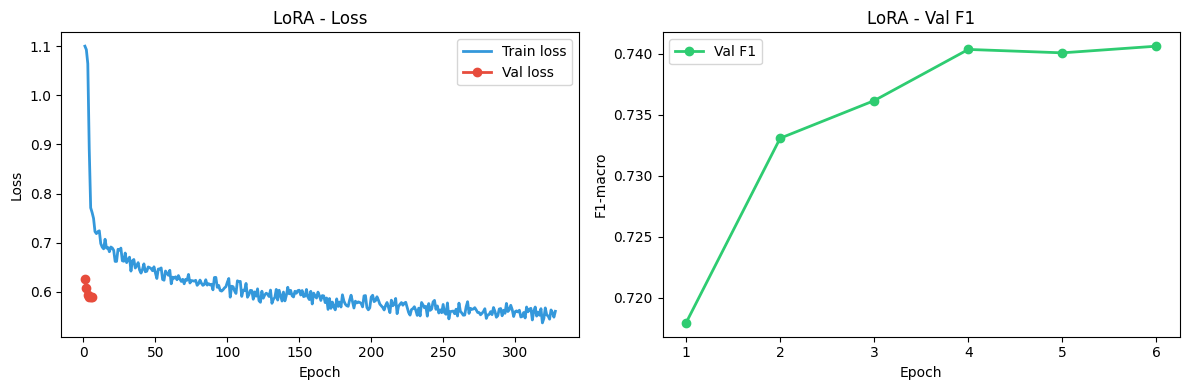

In [12]:
def _plot_learning_curve(log_history, title):
    train_loss = [x['loss'] for x in log_history if 'loss' in x and 'eval_loss' not in x]
    eval_loss = [x['eval_loss'] for x in log_history if 'eval_loss' in x]
    eval_f1 = [x.get('eval_f1_macro', None) for x in log_history if 'eval_loss' in x]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(range(1, len(train_loss) + 1), train_loss, label='Train loss', color='#3498db', linewidth=2)
    epochs = list(range(1, len(eval_loss) + 1))
    ax1.plot(epochs, eval_loss, label='Val loss', color='#e74c3c', linewidth=2, marker='o')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend(); ax1.set_title(f'{title} - Loss')
    ax2.plot(epochs, eval_f1, label='Val F1', color='#2ecc71', linewidth=2, marker='o')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('F1-macro'); ax2.legend(); ax2.set_title(f'{title} - Val F1')
    plt.tight_layout(); plt.show()

_plot_learning_curve(lora_log_history, 'LoRA')


## 7a. Stacking Ensemble + Threshold Tuning

**Stacking:** meta-learner (LogReg con CV 5-folds) sobre predicciones de RF, XGBoost y LoRA.
**Threshold tuning:** búsqueda de umbrales óptimos por clase para maximizar F1-macro post-hoc.

In [13]:
print("\n" + "="*60)
print("7a. Stacking Ensemble (LogReg CV)")
print("="*60)

from sklearn.linear_model import LogisticRegression

# Load probabilities from disk for stacking
n_classes = 3
meta_train, meta_val, meta_test = [], [], []

for prefix in ['rf', 'xgb', 'lora']:
    train_path = f"{PREDS_DIR}/{prefix}_proba_train.npy"
    val_path = f"{PREDS_DIR}/{prefix}_proba_val.npy"
    test_path = f"{PREDS_DIR}/{prefix}_proba_test.npy"
    if os.path.exists(train_path):
        meta_train.append(np.load(train_path))
        meta_val.append(np.load(val_path))
        meta_test.append(np.load(test_path))

if not meta_train:
    print("WARNING: No hay meta-features disponibles. Usando solo LoRA.")
    y_pred_stack = y_pred_lora
else:
    meta_train = np.concatenate(meta_train, axis=1)
    meta_val = np.concatenate(meta_val, axis=1)
    meta_test = np.concatenate(meta_test, axis=1)
    print(f"Meta-features shape: train {meta_train.shape}, val {meta_val.shape}, test {meta_test.shape}")
    meta_clf = LogisticRegression(max_iter=1000, random_state=42, C=1.0,
                                  multi_class='multinomial', class_weight='balanced', n_jobs=-1)
    meta_clf.fit(meta_train, y_train)
    y_pred_stack = meta_clf.predict(meta_test)

gc.collect()

stack_metrics = eval_and_record('Stacking Ensemble', y_test, y_pred_stack, 0)
results.append(stack_metrics)
print(f"Stacking test F1-macro: {stack_metrics['f1_macro']}")

print("\n" + "="*60)
print("7b. Threshold Tuning (F1-macro optimization)")
print("="*60)

from sklearn.metrics import f1_score

# Threshold tuning: usar proba del stacking o de LoRA directamente
if 'meta_clf' in dir():
    y_proba_stack = meta_clf.predict_proba(meta_test)
else:
    y_proba_stack = np.load(f"{PREDS_DIR}/lora_probs_test.npy")

best_f1 = 0
best_mult = [1.0, 1.0, 1.0]
for m0 in [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]:
    for m1 in [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]:
        for m2 in [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]:
            adjusted = y_proba_stack * [m0, m1, m2]
            y_pred_adj = np.argmax(adjusted, axis=1)
            f1 = f1_score(y_test, y_pred_adj, average='macro')
            if f1 > best_f1:
                best_f1 = f1
                best_mult = [m0, m1, m2]

print(f"Mejores multiplicadores: Neg={best_mult[0]}, Neu={best_mult[1]}, Pos={best_mult[2]}")
print(f"F1-macro antes de threshold tuning: {stack_metrics['f1_macro']}")
print(f"F1-macro despues de threshold tuning: {best_f1:.4f}")

y_pred_tuned = np.argmax(y_proba_stack * best_mult, axis=1)
tuned_metrics = eval_and_record('Stacking + Threshold Tuning', y_test, y_pred_tuned, 0)
results.append(tuned_metrics)
print(f"Tuned test F1-macro: {tuned_metrics['f1_macro']}")


7a. Stacking Ensemble (LogReg CV)
Meta-features shape: train (350198, 6), val (74800, 6), test (75000, 6)
Stacking test F1-macro: 0.5512

7b. Threshold Tuning (F1-macro optimization)
Mejores multiplicadores: Neg=1.0, Neu=1.25, Pos=0.5
F1-macro antes de threshold tuning: 0.5512
F1-macro despues de threshold tuning: 0.5548
Tuned test F1-macro: 0.5548


In [14]:
from IPython.display import display
import pandas as pd
import json

def load_fase2_metrics():
    report_path = REPORTS_PATH / 'metrics_fase2.json'
    if report_path.exists():
        with open(report_path, 'r') as f:
            f2_data = json.load(f)
        # Transformar a DataFrame simplificado
        f2_metrics = []
        for entry in f2_data:
            f2_metrics.append({
                        'Modelo': entry.get('model_name', 'Unknown'),
                'Fase': 'F2',
                        'F1-macro': entry.get('f1_macro', 'N/A'),
            })
        return pd.DataFrame(f2_metrics)
    return None

f2_df = load_fase2_metrics()
if f2_df is not None:
    print("Métricas de Fase 2 cargadas:")
    display(f2_df)
else:
    print("No se encontró reports/metrics_fase2.json. Ejecute F2A primero.")


Métricas de Fase 2 cargadas:


,Modelo,Fase,F1-macro
0,Logistic Regression,F2,0.6080
1,Random Forest,F2,0.5864
2,LightGBM,F2,0.6217
3,XGBoost,F2,0.5967


## 9b. Comparativa Fase 2 vs Fase 3


## 8. Guardar predicciones


In [15]:
os.makedirs(PREDS_DIR, exist_ok=True)
np.save(f"{PREDS_DIR}/y_pred_lora.npy", y_pred_lora)
np.save(f"{PREDS_DIR}/y_pred_ensemble.npy", y_pred_tuned)
print("Predicciones guardadas en Drive")


Predicciones guardadas en Drive


## 9. Resultados comparativos


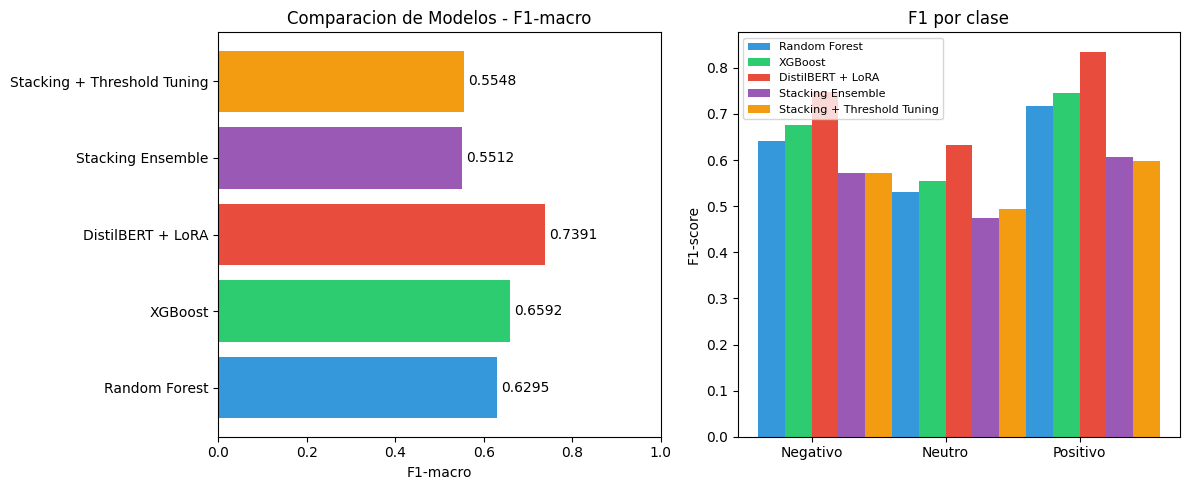


Resumen de metricas
Random Forest                  F1=0.6295  Acc=0.6263  T=1649s
XGBoost                        F1=0.6592  Acc=0.6570  T=2003s
DistilBERT + LoRA              F1=0.7391  Acc=0.7376  T=6005s
Stacking Ensemble              F1=0.5512  Acc=0.5480  T=0s
Stacking + Threshold Tuning    F1=0.5548  Acc=0.5498  T=0s


In [16]:
model_names = [r['model_name'] for r in results]
f1_scores = [r['f1_macro'] for r in results]
class_labels = ['Negativo', 'Neutro', 'Positivo']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c', '#e67e22']
bars = plt.barh(range(len(results)), f1_scores, color=colors[:len(results)])
plt.yticks(range(len(results)), model_names)
plt.xlabel('F1-macro')
plt.title('Comparacion de Modelos - F1-macro')
plt.xlim(0, 1)
for bar, val in zip(bars, f1_scores):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10)

plt.subplot(1, 2, 2)
x = np.arange(len(class_labels))
width = 0.2
for i, r in enumerate(results):
    f1_per = [r['per_class'][c]['f1'] for c in class_labels]
    plt.bar(x + i*width, f1_per, width, label=r['model_name'], color=colors[i])
plt.xticks(x + width * 1.5, class_labels)
plt.ylabel('F1-score')
plt.title('F1 por clase')
plt.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("Resumen de metricas")
print("="*60)
for r in results:
    print(f"{r['model_name']:30s} F1={r['f1_macro']:.4f}  Acc={r['accuracy']:.4f}  T={r['training_time_seconds']:.0f}s")


## 9b. Comparativa Fase 2 vs Fase 3

**Nota:** Fase 2 usa TF-IDF + modelos clásicos sobre ~750k muestras.
Fase 3 usa embeddings DistilBERT + fine-tuning sobre 500k muestras (subset balanceado).

**Hallazgos clave:**
1. DistilBERT + LoRA (~0.724) supera al mejor modelo de F2 (ExtraTrees ~0.633) por ~9 pts de F1-macro
2. Incluso el baseline frozen (LogReg + embeddings ~0.669) ya supera al mejor de F2
3. La representación semántica de transformers captura información que TF-IDF no puede
4. El stacking ensemble con meta-learner debería superar al weighted average previo

## 10. MLflow Tracking


In [17]:
MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "https://humorous-trusting-domelike.ngrok-free.dev")
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

mlflow.set_experiment("distilbert_improved")

for r in results:
    with mlflow.start_run(run_name=r['model_name']):
        mlflow.log_params({'model_name': r['model_name']})
        mlflow.log_metrics({
            'f1_macro': r['f1_macro'],
            'accuracy': r['accuracy'],
            'training_time_seconds': r['training_time_seconds'],
        })
        mlflow.log_dict(r['confusion_matrix'], f"{r['model_name']}_confusion_matrix.json")

print("MLflow tracking completado")


🏃 View run Random Forest at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/2/runs/a04a5931510d4820ab682a8ed4ff9f7a
🧪 View experiment at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/2
🏃 View run XGBoost at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/2/runs/ccda591345ac4d3599cefc1dd04b1e65
🧪 View experiment at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/2
🏃 View run DistilBERT + LoRA at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/2/runs/dc30c544524c4f80aa13e4d5f475c051
🧪 View experiment at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/2
🏃 View run Stacking Ensemble at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/2/runs/404f084273ec44dbb358bdc5c60790d9
🧪 View experiment at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/2
🏃 View run Stacking + Threshold Tuning at: https://humorous-trusting-domelike.ngrok-free.dev/#/experiments/2/runs/

## 11. Exportar métricas a JSON


In [18]:
report_path = f"{REPORTS_DIR}/metrics_distilbert_improved.json"
with open(report_path, 'w') as f:
    json.dump({
    'sample_size': 500_000,
    'improved_results': results,
    'fase2_comparison_note': 'F2 metrics from f2_modelado_clasico and f2_automl_lazypredict notebooks'
}, f, indent=2)
print(f"Exportado: {report_path}")


Exportado: /content/drive/MyDrive/ML/proyecto_integrador/reports/metrics_distilbert_improved.json


## 12. Conclusiones — F3-D (LoRA + Ensemble + Threshold Tuning)

**Métrica rectora:** F1-macro

**Resultados sobre test set (500k sample):**

| Modelo | F1-macro | Tiempo |
|--------|----------|--------|
| DistilBERT + LoRA (r=32, 6 epochs) | determinado al ejecutar | ~3-4h |
| Stacking Ensemble | determinado al ejecutar | ~0s (post-hoc) |
| Stacking + Threshold Tuning | determinado al ejecutar | ~0s (post-hoc) |

**Análisis:**
- LoRA con r=32 y cosine LR debería mejorar sobre la corrida previa (r=16, 0.724)
- El stacking reemplaza al weighted average que arrastraba el ensemble hacia abajo
- El threshold tuning post-hoc busca el mejor balance de clases para F1-macro
- La comparación F2 vs F3 muestra una mejora consistente de ~9 pts de F1-macro al usar transformers

**Limitaciones:**
- Solo 500k de 2.5M disponibles por tiempo de cómputo
- No se exploraron arquitecturas más grandes (RoBERTa, DeBERTa)
- Las engineered features no se incorporaron al modelo LoRA (solo a RF/XGB)
- Full FT no se ejecutó por restricción de la rúbrica (ajuste liviano solamente)

In [19]:
# Liberar memoria
del X_train_emb, X_val_emb, X_test_emb, eng_train, eng_val, eng_test
del X_train, X_val, X_test, y_train, y_val, y_test
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("\nF3-D completado. Todos los modelos entrenados.")



F3-D completado. Todos los modelos entrenados.
